# ПГО на основании анализа исторических данных

## Что мы хотим
- построить алгоритм поиска грубых ошибок на основе ИИ техник
- решать задачу ПГО быстро

In [15]:
import warnings
warnings.filterwarnings('ignore')
import sys

from datetime import datetime
import pandas as pd
from IPython.display import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input, Model

sys.path.append('./graph_generator')
from graph_generator import GraphGenerator
pd.set_option('display.precision', 2)

ModuleNotFoundError: No module named 'graph_generator'

In [16]:
import os
os.getcwd()

'C:\\YandexDisk\\zyfra\\zmeb_GED_ML_research\\researches'

## Данные

### Граф

### Вспомогательные функции

In [ ]:
pd.set_option('display.max_columns', 100)
gg = GraphGenerator(layer_sizes=[50, 50, 50])
gg.build()
gg.fill_with_values()
d1 = gg.build_pivot_table(10_000)
d2 = gg.build_pivot_table(10_000)
df = pd.concat([d1, d2])
df.head()

In [ ]:
flow_names = list(gg.graph.edges.keys())
nodes_names =list(gg.graph.nodes.keys())
x_cols = flow_names + nodes_names
y_cols = [col+'_diff' for col in x_cols if col in flow_names]

print('количество потоков:', len(flow_names))
print('количество узлов:', len(nodes_names))
print(f'средняя связность графа: {(len(flow_names) / len(nodes_names)):.1f}')

print(f'x columns: {x_cols[:10]}...')
print()
print(f'y columns: {y_cols[:10]}...')

### Делим выборку на тренировочную, валидационную и тестовую

In [7]:
from sklearn.model_selection import train_test_split
df_train, dd = train_test_split(df.sample(len(df)), test_size=2/5)
df_val, df_test = train_test_split(dd, test_size=.5)
print(f'В тренировочной выборке :  {len(df_train)} строк')
print(f'В валидационной выборке :  {len(df_val)}   строк')
print(f'В тестовой выборке      :  {len(df_test)}  строк')

df_train_x, df_train_y = df_train[x_cols], df_train[y_cols]
df_val_x, df_val_y = df_val[x_cols], df_val[y_cols]
df_test_x, df_test_y = df_test[x_cols], df_test[y_cols]

В тренировочной выборке :  6000 строк
В валидационной выборке :  2000   строк
В тестовой выборке      :  2000  строк


## Модель

In [8]:
Image("nn.png", width=800, height=800)

FileNotFoundError: No such file or directory: 'nn.png'

FileNotFoundError: No such file or directory: 'nn.png'

<IPython.core.display.Image object>

### Создаем модель

In [9]:
input_dim = df_train_x.shape[1]
output_dim = df_train_y.shape[1]

mod = tf.keras.models.Sequential([
    
    # deconstruct / encode
    tf.keras.layers.Dense(input_dim * 2, activation='relu', input_shape=(input_dim, )), 
    tf.keras.layers.Dense(int(input_dim * 1.6) , activation='relu'),
    tf.keras.layers.Dense(int(input_dim * 1.3) , activation='relu'),
    tf.keras.layers.Dense(input_dim, activation='relu'),
    tf.keras.layers.Dense(output_dim)
])

mod.compile(
    optimizer="adam", 
    loss="mse", 
    metrics=["mse"])

mod.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 780)               304980    
                                                                 
 dense_1 (Dense)             (None, 624)               487344    
                                                                 
 dense_2 (Dense)             (None, 507)               316875    
                                                                 
 dense_3 (Dense)             (None, 390)               198120    
                                                                 
 dense_4 (Dense)             (None, 239)               93449     
                                                                 
Total params: 1,400,768
Trainable params: 1,400,768
Non-trainable params: 0
_________________________________________________________________


### Обучение

In [7]:
BATCH_SIZE = 128
EPOCHS = 200

yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')
log_subdir = f"{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(mod.layers)}"

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=.001,
    patience=10,
    verbose=2, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='mod.hdf5',
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/{log_subdir}',
    batch_size=BATCH_SIZE,
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

history = mod.fit(
    df_train_x, df_train_y,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(df_val_x, df_val_y)
)

Epoch 1/200
47/47 [==============================] - 2s 22ms/step - loss: 0.0538 - mse: 0.0538 - val_loss: 0.0461 - val_mse: 0.0461
Epoch 2/200
47/47 [==============================] - 1s 17ms/step - loss: 0.0453 - mse: 0.0453 - val_loss: 0.0438 - val_mse: 0.0438
Epoch 3/200
47/47 [==============================] - 1s 17ms/step - loss: 0.0423 - mse: 0.0423 - val_loss: 0.0405 - val_mse: 0.0405
Epoch 4/200
47/47 [==============================] - 1s 17ms/step - loss: 0.0385 - mse: 0.0385 - val_loss: 0.0379 - val_mse: 0.0379
Epoch 5/200
47/47 [==============================] - 1s 21ms/step - loss: 0.0358 - mse: 0.0358 - val_loss: 0.0353 - val_mse: 0.0353
Epoch 6/200
47/47 [==============================] - 1s 18ms/step - loss: 0.0341 - mse: 0.0341 - val_loss: 0.0340 - val_mse: 0.0340
Epoch 7/200
47/47 [==============================] - 1s 19ms/step - loss: 0.0322 - mse: 0.0322 - val_loss: 0.0324 - val_mse: 0.0324
Epoch 8/200
47/47 [==============================] - 1s 20ms/step - loss: 0.

## Оценка результатов модели

### На тестовой выборке

In [8]:
df_test_res = mod.predict(df_test_x)
mse = np.mean(np.power(df_test_y - df_test_res, 2), axis=1)
print(f'MAE на тестовой выборке: {np.mean(mse):.2f}')

63/63 [==============================] - 0s 4ms/step
MAE на тестовой выборке: 0.02


In [9]:
len(df_test_res)

2000

### Визуальный анализ 

In [10]:
pd.set_option('display.max_columns', 30)

d = df_test_x.copy()

df_test_res = mod.predict(df_test_x)
df_test_res = pd.DataFrame(df_test_res, columns=df_test_y.columns)
df_test_res.index = d.index.copy()
df_test_res[df_test_res < 0] = 0
d = pd.concat([d, df_test_res], axis=1)

d.sample(5)

63/63 [==============================] - 0s 4ms/step


,env -> 0:0,0:0 -> 1:2,env -> 0:1,0:1 -> 1:3,env -> 0:2,0:2 -> 1:18,env -> 0:3,0:3 -> 1:15,env -> 0:4,0:4 -> 1:12,env -> 0:5,0:5 -> 1:9,env -> 0:6,0:6 -> 1:4,env -> 0:7,...,1:44 -> 2:38_diff,2:38 -> env_diff,2:39 -> env_diff,2:40 -> env_diff,2:41 -> env_diff,1:36 -> 2:42_diff,2:42 -> env_diff,2:43 -> env_diff,2:44 -> env_diff,2:45 -> env_diff,2:46 -> env_diff,1:27 -> 2:47_diff,2:47 -> env_diff,2:48 -> env_diff,2:49 -> env_diff
4954,0.20,0.28,2.26,2.15,1.19,1.11,0.49,0.49,2.05,1.59,3.43,3.43,3.49,0.70,0.23,...,0.00e+00,7.47e-03,0.04,0.00,0.00,0.00,0.01,3.68e-02,0.17,0.00,0.04,0.08,1.54e-02,0.00e+00,0.04
1601,0.50,0.50,1.14,1.14,1.40,1.40,2.48,3.47,0.39,0.28,0.86,0.83,2.21,1.16,2.73,...,3.81e-02,5.16e-02,0.01,0.00,0.03,0.02,0.07,2.86e-02,0.17,0.01,0.07,0.03,9.84e-03,1.29e-02,0.13
136,1.86,1.86,2.76,1.87,1.55,1.55,0.90,0.90,0.33,0.11,1.93,1.93,1.65,0.69,1.38,...,6.28e-03,4.08e-02,0.02,0.06,0.02,0.05,0.06,7.18e-03,0.07,0.00,0.07,0.03,1.17e-03,4.04e-03,0.14
8503,3.70,3.70,4.43,4.43,0.20,0.20,0.37,0.37,1.97,1.20,1.80,1.80,2.56,1.41,2.02,...,0.00e+00,0.00e+00,0.04,0.00,0.05,0.08,0.10,1.51e-02,0.41,1.27,0.00,0.02,0.00e+00,1.54e+00,0.15
9191,2.55,2.55,0.87,0.70,2.64,2.64,2.11,2.11,2.65,0.65,2.08,2.56,2.76,1.04,2.96,...,5.95e-03,7.01e-02,0.32,0.37,0.05,0.00,0.04,1.35e-02,0.53,0.02,0.00,0.05,3.44e-02,2.31e-02,0.04


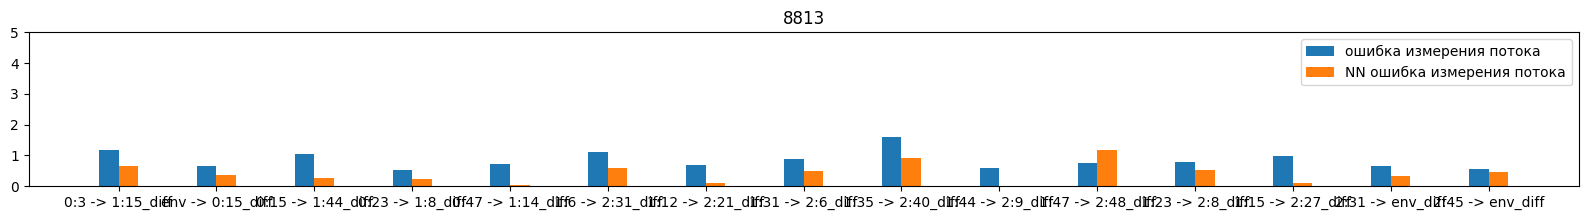

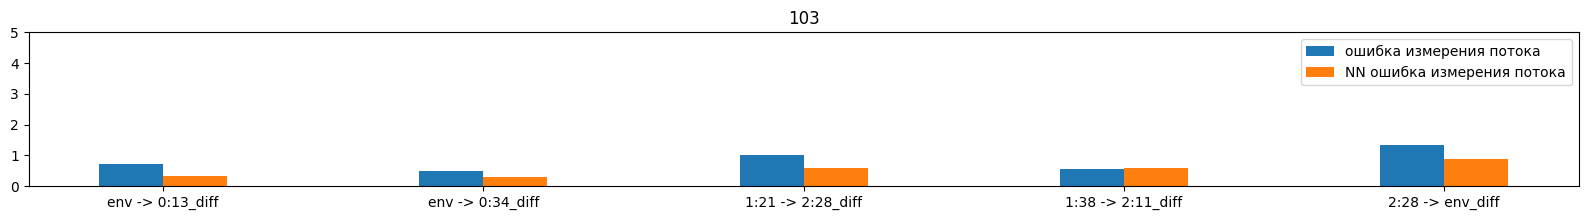

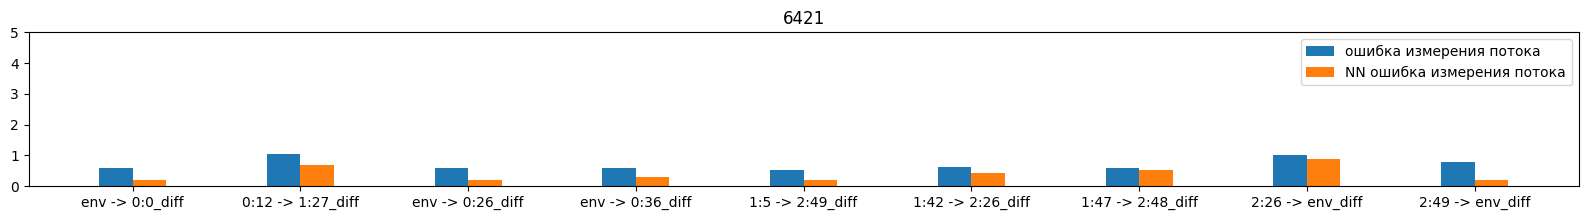

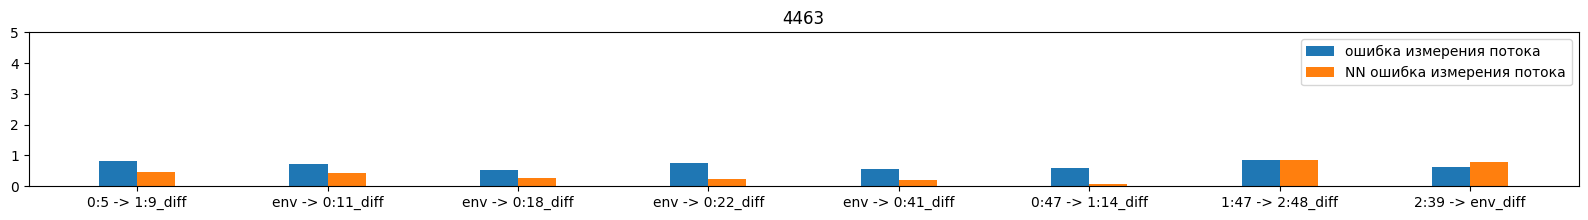

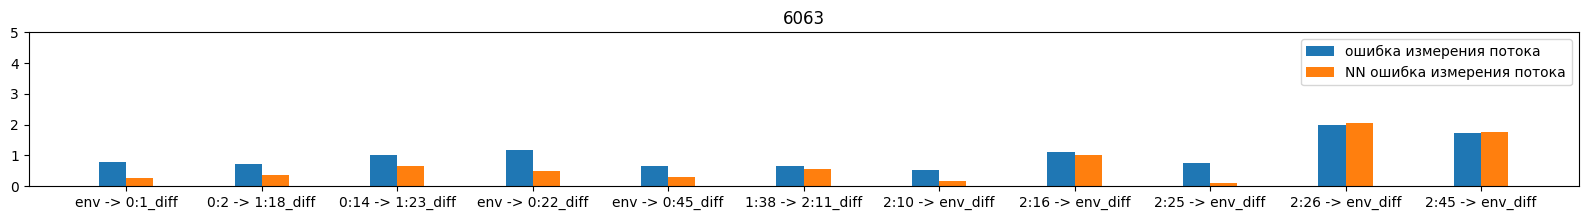

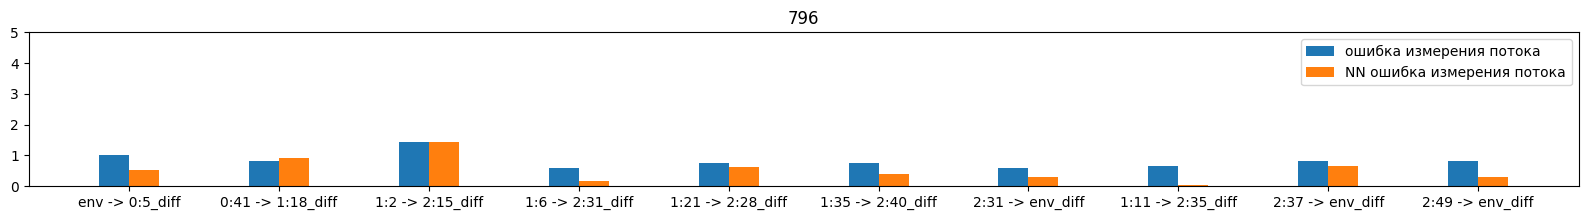

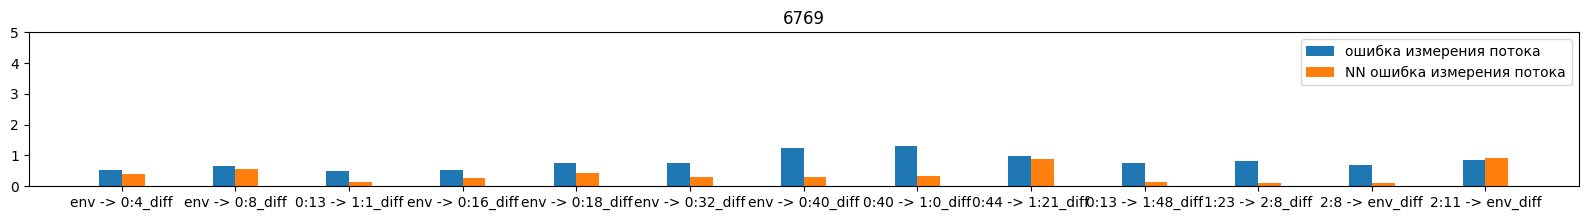

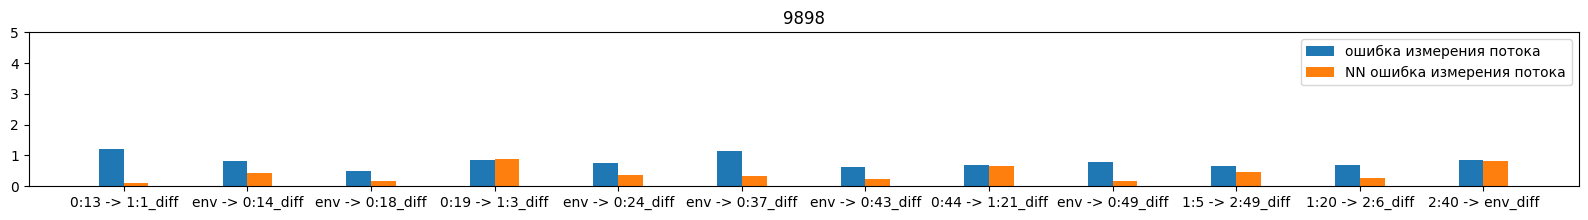

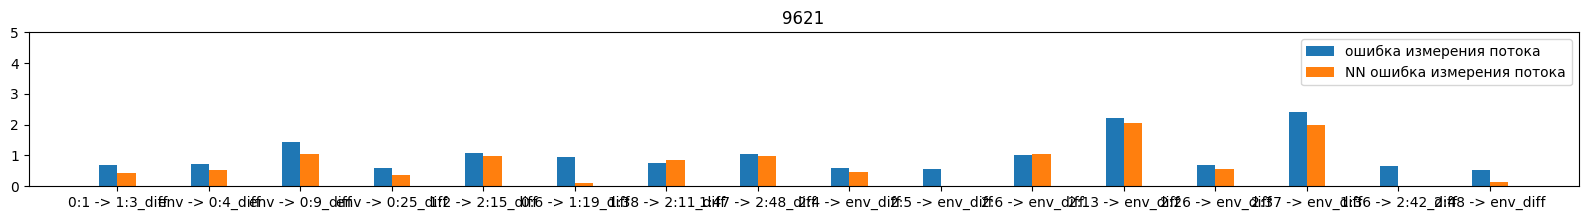

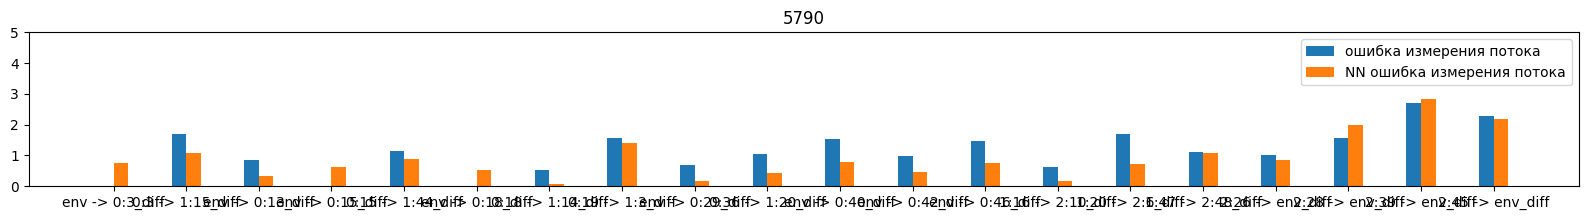

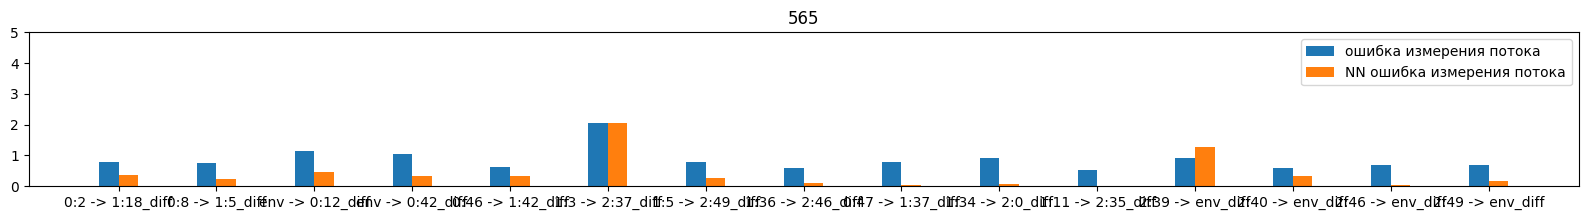

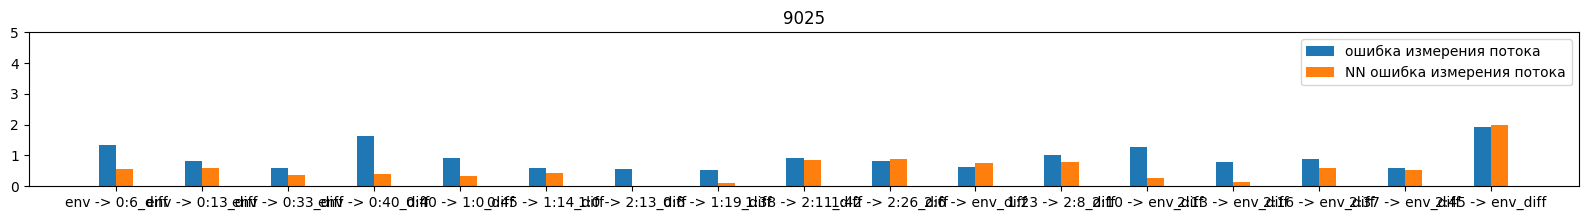

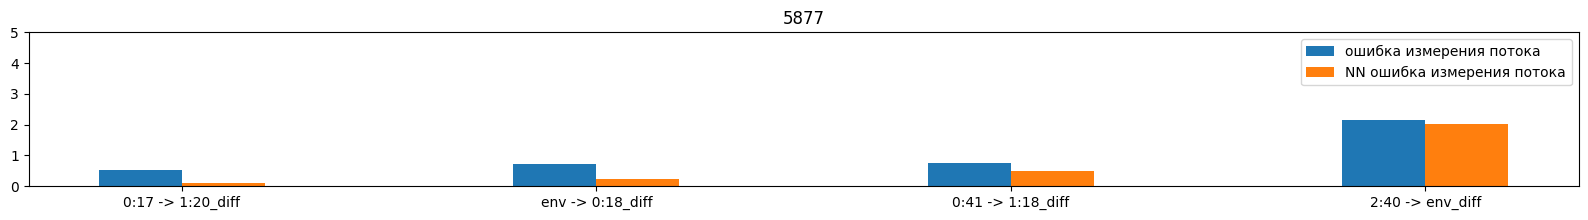

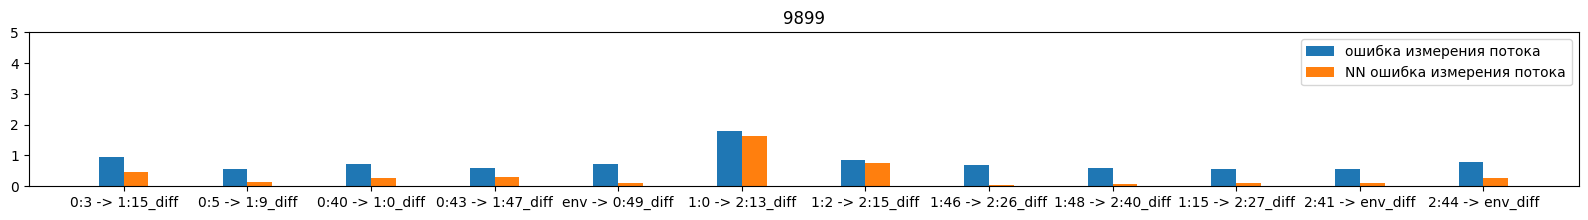

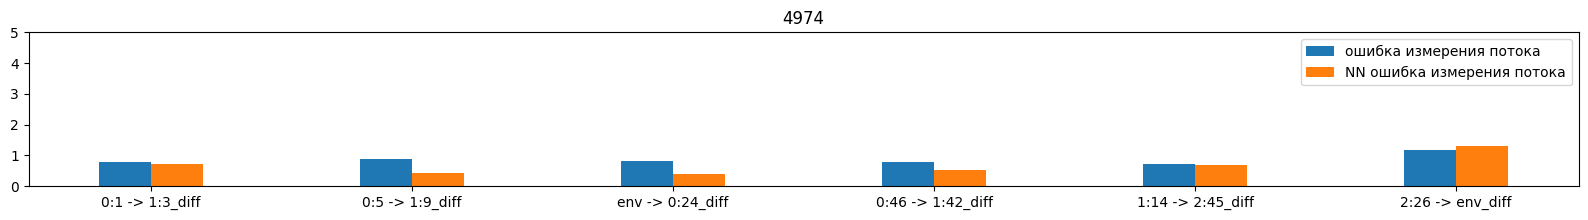

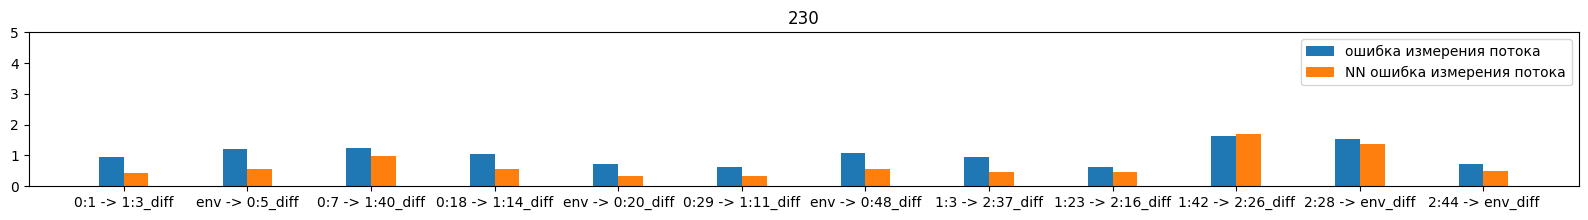

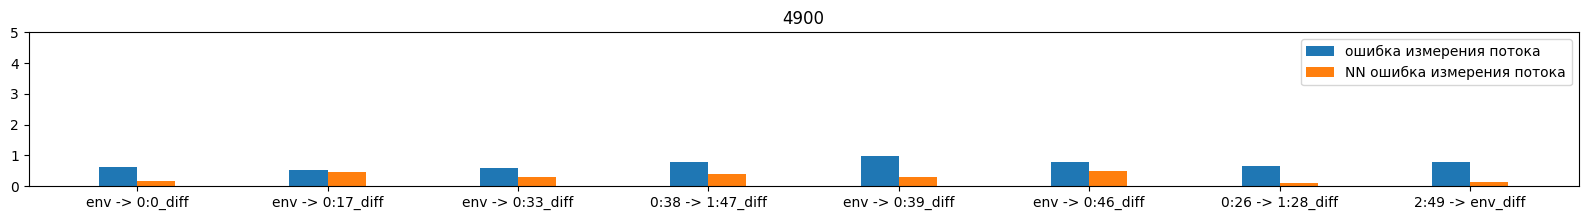

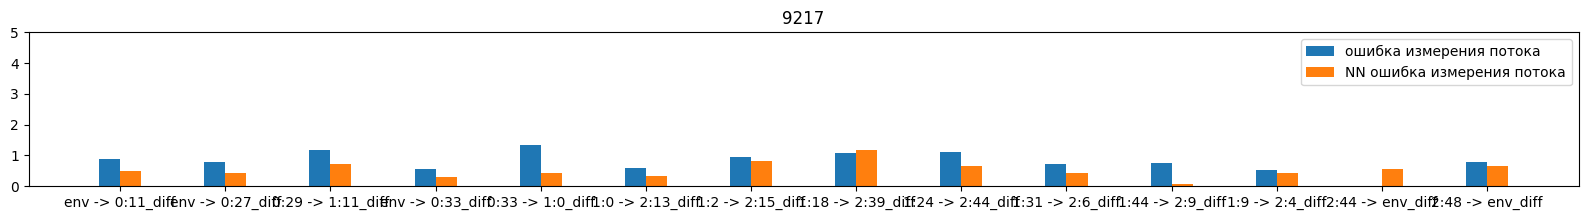

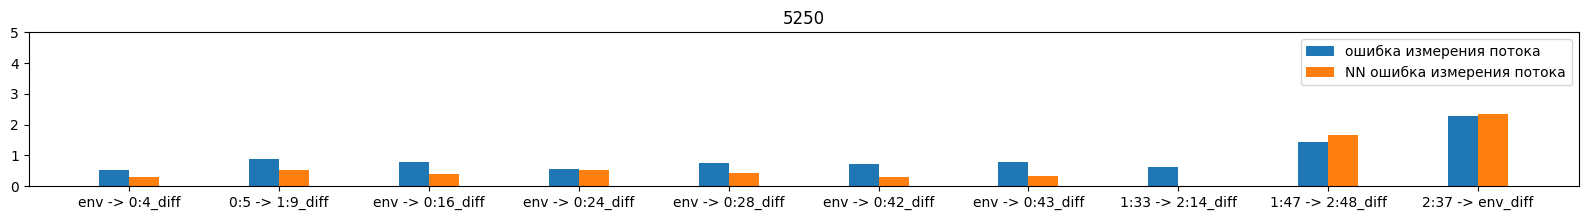

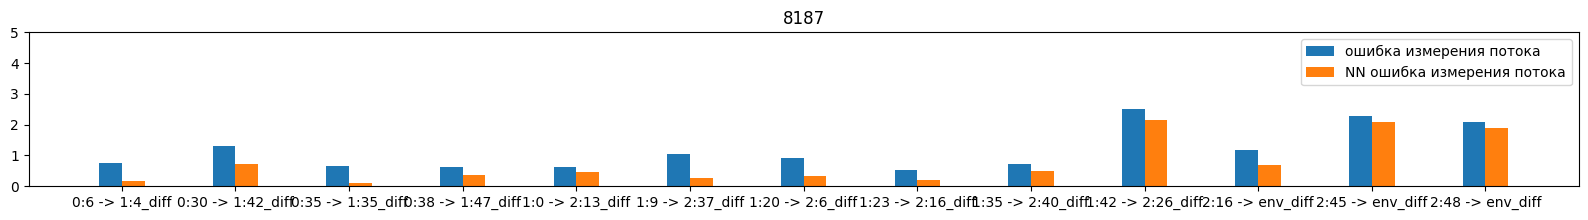

In [15]:
d1 = df_test.sample(20)

for i1, row1 in d1[y_cols].iterrows():
    plt.figure(figsize=(20, 2))
    row2 = d[y_cols][d.index == i1].iloc[0]
    mask = [(r1 > .5) or (r2 > .5) for r1, r2 in zip(row1, row2)]
    #mask = [True for i in range(len(row1))]
    row11 = row1[mask]
    row22 = row2[mask]
    w=.2
    indexes1 = [ii - w/2 for ii in range(len(row11.index))]
    indexes2 = [ii + w/2 for ii in range(len(row22.index))]
    plt.bar(indexes1, row11, width=w, label='ошибка измерения потока')
    plt.bar(indexes2, row22, width=w, label= 'NN ошибка измерения потока')
    plt.xticks(range(len(row11)), row11.index)
    plt.title(i1)
    plt.legend()
    if row11.max() < 5 or row22.max() < 5:
        plt.ylim((min(row1.min(), row2.min()), 5))
    plt.show()